In [48]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

class TradingGymEnv(gym.Env):
    def __init__(
        self,
        df,
        state_features,
        transaction_cost=0.001,
        lambda_vol=0.01,
        lambda_dd=0.02,
        reward_clip=None
    ):
        super().__init__()

        self.df = df.reset_index(drop=True).copy()
        self.state_features = state_features
        self.transaction_cost = transaction_cost
        self.lambda_vol = lambda_vol
        self.lambda_dd = lambda_dd
        self.reward_clip = reward_clip
        self.n_steps = len(self.df)

        required_cols = ["raw_return_1d", "regime_volatility"]
        missing_cols = [c for c in required_cols if c not in self.df.columns]
        if missing_cols:
            raise ValueError(f"DataFrame is missing required columns: {missing_cols}")

        # 5 discrete target positions
        # 0 -> 0%, 1 -> 25%, 2 -> 50%, 3 -> 75%, 4 -> 100%
        self.action_space = spaces.Discrete(5)
        self.position_levels = np.array([0.0, 0.25, 0.5, 0.75, 1.0], dtype=np.float32)

        # Observation = state_features + current position
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.state_features) + 1,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0.0
        self.total_reward = 0.0
        self.portfolio_value = 1.0
        self.running_max = 1.0

        state = self._get_state()
        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step
        }
        return state, info

    def _get_state(self):
        market_state = self.df.loc[self.current_step, self.state_features].values.astype(np.float32)
        full_state = np.append(market_state, np.float32(self.position))
        return full_state.astype(np.float32)

    def step(self, action):
        reward = 0.0

        # Stop before next-day return becomes unavailable
        if self.current_step >= self.n_steps - 2:
            terminated = True
            truncated = False
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)
            info = {
                "portfolio_value": self.portfolio_value,
                "position": self.position,
                "step": self.current_step
            }
            return next_state, reward, terminated, truncated, info

        action = int(action)
        target_position = float(self.position_levels[action])

        # Transaction cost depends on how much position changes
        position_change = abs(target_position - self.position)
        trade_cost = position_change * self.transaction_cost

        # Apply new position
        self.position = target_position

        # Next-day raw return drives PnL
        next_return = float(self.df.loc[self.current_step + 1, "raw_return_1d"])
        pnl = self.position * next_return

        # Risk penalties
        current_vol = float(self.df.loc[self.current_step, "regime_volatility"])
        current_drawdown = max(
            0.0,
            (self.running_max - self.portfolio_value) / (self.running_max + 1e-8)
        )

        reward = pnl - trade_cost - self.lambda_vol * current_vol - self.lambda_dd * current_drawdown

        if self.reward_clip is not None:
            reward = float(np.clip(reward, -self.reward_clip, self.reward_clip))
        else:
            reward = float(reward)

        # Update portfolio
        self.total_reward += reward
        self.portfolio_value *= (1 + reward)
        self.running_max = max(self.running_max, self.portfolio_value)

        # Move forward
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 2
        truncated = False

        if not terminated:
            next_state = self._get_state()
        else:
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)

        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step,
            "trade_cost": trade_cost,
            "pnl": pnl,
            "drawdown": current_drawdown
        }

        return next_state, reward, terminated, truncated, info

In [49]:
import pandas as pd
import numpy as np

# ================================
# Load dataset
# ================================
df_all = pd.read_csv("global_trading_dataset.csv")

# Convert date
df_all["date"] = pd.to_datetime(df_all["date"])

# Sort by market and time
df_all = df_all.sort_values(["market", "date"]).reset_index(drop=True)

# Ensure numeric columns are float
numeric_cols = ["open", "high", "low", "close", "volume"]
df_all[numeric_cols] = df_all[numeric_cols].astype(float)

# ================================
# Create core return features
# ================================
df_all["raw_return_1d"] = df_all.groupby("market")["close"].pct_change()

df_all["return_5d"] = (
    df_all.groupby("market")["close"].pct_change(5)
)

df_all["return_10d"] = (
    df_all.groupby("market")["close"].pct_change(10)
)

# ================================
# Moving averages
# ================================
df_all["MA_5"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(5).mean())
)

df_all["MA_20"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(20).mean())
)

df_all["MA_gap"] = (df_all["MA_5"] / df_all["MA_20"]) - 1

# Trend strength feature (important for PPO)
df_all["trend_strength"] = df_all["MA_gap"]

# Bull / Bear regime indicator
df_all["bull_flag"] = (df_all["MA_5"] > df_all["MA_20"]).astype(int)

# ================================
# Volatility features
# ================================
df_all["volatility_10"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(10).std())
)

# Regime volatility (used in reward)
df_all["regime_volatility"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(20).std())
)

# ================================
# Volume change
# ================================
df_all["volume_change"] = (
    df_all.groupby("market")["volume"].pct_change()
)

# ================================
# RSI (14)
# ================================
def compute_rsi(series, window=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))

    return rsi

df_all["RSI_14"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: compute_rsi(x, 14))
)

# ================================
# MACD
# ================================
ema12 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=12).mean())
ema26 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=26).mean())

df_all["MACD"] = ema12 - ema26

# ================================
# Position feature placeholder
# (used by RL environment)
# ================================
df_all["position_feature"] = 0.0

# ================================
# Clean NaN / Inf values
# ================================
df_all = df_all.replace([np.inf, -np.inf], np.nan)

df_all = df_all.dropna().reset_index(drop=True)

# ================================
# Dataset diagnostics
# ================================
print("Dataset shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())

print("\nHead:")
print(df_all.head())

print("\nMarket distribution:")
print(df_all["market"].value_counts())

print("\nNaN count:")
print(df_all.isna().sum())

print("\nInf count:")
print(np.isinf(df_all.select_dtypes(include=[float, int])).sum())

Dataset shape: (7258, 22)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'market', 'return_1d', 'return_5d', 'return_10d', 'MA_5', 'MA_20', 'MA_gap', 'volatility_10', 'volume_change', 'RSI_14', 'MACD', 'raw_return_1d', 'trend_strength', 'bull_flag', 'regime_volatility', 'position_feature']

Head:
        date        close         high          low         open    volume  \
0 2020-03-05  3071.677002  3074.257080  3022.926025  3036.155029  445400.0   
1 2020-03-06  3034.510986  3052.444092  3029.462891  3039.939941  362100.0   
2 2020-03-09  2943.291016  2989.205078  2940.714111  2987.180908  414600.0   
3 2020-03-10  2996.761963  3000.295898  2904.799072  2918.935059  393300.0   
4 2020-03-11  2968.517090  3010.029053  2968.517090  3001.761963  352500.0   

  market  return_1d  return_5d  return_10d  ...    MA_gap  volatility_10  \
0     CN   0.019926   0.026860    0.013703  ...  0.005506       0.018136   
1     CN  -0.012100   0.053538   -0.001697  ...  0.013188       0.01

In [50]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ======================================
# State features
# ======================================
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

state_features = base_features + regime_features
# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# it must never be scaled
scale_cols = base_features + regime_features

# ======================================
# Utility: time split
# ======================================
def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test

# ======================================
# Prepare RL dataframe
# ======================================
df_rl = df_all.copy()

df_rl = df_rl.replace([np.inf, -np.inf], np.nan)
df_rl = df_rl.dropna(subset=state_features).reset_index(drop=True)

# ======================================
# Use US market first for initial PPO testing
# ======================================
df_us = (
    df_rl[df_rl["market"] == "US"]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

# Split before scaling to avoid leakage
df_us_train, df_us_val, df_us_test = time_split(df_us, train_ratio=0.6, val_ratio=0.2)

print("US split sizes:")
print("Train:", df_us_train.shape)
print("Val  :", df_us_val.shape)
print("Test :", df_us_test.shape)

# ======================================
# Fit scaler on TRAIN only
# ======================================
scaler = StandardScaler()
df_us_train[scale_cols] = scaler.fit_transform(df_us_train[scale_cols])
df_us_val[scale_cols] = scaler.transform(df_us_val[scale_cols])
df_us_test[scale_cols] = scaler.transform(df_us_test[scale_cols])

# ======================================
# Data quality checks
# ======================================
for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n===== {name} =====")
    print("NaN count:")
    print(df_part[state_features].isna().sum())

    print("\nInf count:")
    print(np.isinf(df_part[scale_cols].select_dtypes(include=[float, int]).values).sum())

    print("\nScaled feature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])

# ======================================
# Environment sanity check (train only)
# ======================================
env = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.001,
    lambda_vol=0.01,
    lambda_dd=0.02,
    reward_clip=None
)

obs, info = env.reset()

print("\nInitial state:", obs)
print("Reset info:", info)
print("Observation shape:", obs.shape)
print("Any NaN in obs:", np.isnan(obs).any())
print("Any Inf in obs:", np.isinf(obs).any())

# Random rollout test using new 5-action space
done = False
while not done:
    action = np.random.choice([0, 1, 2, 3, 4])
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print("\nFinal portfolio value:", info["portfolio_value"])
print("Total reward:", env.total_reward)

US split sizes:
Train: (880, 22)
Val  : (293, 22)
Test : (294, 22)

===== TRAIN =====
NaN count:
return_1d            0
return_5d            0
return_10d           0
MA_gap               0
volatility_10        0
volume_change        0
RSI_14               0
MACD                 0
trend_strength       0
regime_volatility    0
bull_flag            0
dtype: int64

Inf count:
0

Scaled feature summary:
                           mean       std       min       max
return_1d         -4.037175e-18  1.000569 -7.984855  6.185860
return_5d          0.000000e+00  1.000569 -6.160840  5.808628
return_10d        -1.614870e-17  1.000569 -5.740148  4.488765
MA_gap             1.614870e-17  1.000569 -5.589957  3.110504
volatility_10     -7.266914e-17  1.000569 -1.006580  6.778218
volume_change     -1.009294e-17  1.000569 -5.412564  6.719046
RSI_14            -3.229740e-16  1.000569 -2.694469  2.295799
MACD               3.229740e-17  1.000569 -4.456724  1.678690
trend_strength     1.614870e-17  1.00056

In [51]:
import numpy as np

print("Checking RL dataset quality...")

for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n==================== {name} ====================")

    # NaN check
    print("\nNaN count per feature:")
    print(df_part[state_features].isna().sum())

    # Inf check
    print("\nInf count in scaled features:")
    print(np.isinf(df_part[scale_cols].values).sum())

    # Extreme value check
    print("\nMax absolute value per feature:")
    print(np.abs(df_part[scale_cols]).max())

    # Feature statistics
    print("\nFeature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])

    # Position feature check
    print("\nPosition feature unique values:")
    print(df_part["position_feature"].unique())

Checking RL dataset quality...

==================== TRAIN ====================

NaN count per feature:
return_1d            0
return_5d            0
return_10d           0
MA_gap               0
volatility_10        0
volume_change        0
RSI_14               0
MACD                 0
trend_strength       0
regime_volatility    0
bull_flag            0
dtype: int64

Inf count in scaled features:
0

Max absolute value per feature:
return_1d            7.984855
return_5d            6.160840
return_10d           5.740148
MA_gap               5.589957
volatility_10        6.778218
volume_change        6.719046
RSI_14               2.694469
MACD                 4.456724
trend_strength       5.589957
regime_volatility    5.619918
bull_flag            1.339272
dtype: float64

Feature summary:
                           mean       std       min       max
return_1d         -4.037175e-18  1.000569 -7.984855  6.185860
return_5d          0.000000e+00  1.000569 -6.160840  5.808628
return_10d     

In [52]:
# ======================================
# Environment reset sanity checks
# ======================================

def check_env(env, name):
    print(f"\n================ {name} ENV CHECK ================")

    obs, info = env.reset()

    print("Initial obs:", obs)
    print("Obs shape:", obs.shape)
    print("Obs dtype:", obs.dtype)

    print("Action space:", env.action_space)
    print("Action space size:", env.action_space.n)

    print("Any NaN in obs:", np.isnan(obs).any())
    print("Any Inf in obs:", np.isinf(obs).any())

    print("\nReset info:", info)

    # Assertions
    assert obs.shape == (len(state_features) + 1,), f"Unexpected observation shape: {obs.shape}"
    assert env.action_space.n == 5, f"Unexpected action space: {env.action_space}"
    assert not np.isnan(obs).any(), "Observation contains NaN"
    assert not np.isinf(obs).any(), "Observation contains Inf"

    print("\nEnvironment reset check passed.")


# Train environment
env_train = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.001,
    lambda_vol=0.01,
    lambda_dd=0.02,
    reward_clip=None
)

# Validation environment
env_val = TradingGymEnv(
    df=df_us_val,
    state_features=state_features,
    transaction_cost=0.001,
    lambda_vol=0.01,
    lambda_dd=0.02,
    reward_clip=None
)

# Test environment
env_test = TradingGymEnv(
    df=df_us_test,
    state_features=state_features,
    transaction_cost=0.001,
    lambda_vol=0.01,
    lambda_dd=0.02,
    reward_clip=None
)

# Run checks
check_env(env_train, "TRAIN")
check_env(env_val, "VAL")
check_env(env_test, "TEST")


================ TRAIN ENV CHECK ================
Initial obs: [-0.58327395 -3.9689612  -3.1017973  -2.3557148   0.4780189   1.0686506
 -2.5828328  -1.3164753  -2.3557148   0.33237815 -1.3392725   0.        ]
Obs shape: (12,)
Obs dtype: float32
Action space: Discrete(5)
Action space size: 5
Any NaN in obs: False
Any Inf in obs: False

Reset info: {'portfolio_value': 1.0, 'position': 0.0, 'step': 0}

Environment reset check passed.

================ VAL ENV CHECK ================
Initial obs: [ 0.92530864  0.7694009   0.22121732 -0.23696515 -0.3479422   0.6488762
 -0.09381164 -0.47015023 -0.23696515 -0.50350845 -1.3392725   0.        ]
Obs shape: (12,)
Obs dtype: float32
Action space: Discrete(5)
Action space size: 5
Any NaN in obs: False
Any Inf in obs: False

Reset info: {'portfolio_value': 1.0, 'position': 0.0, 'step': 0}

Environment reset check passed.

================ TEST ENV CHECK ================
Initial obs: [ 0.13894847 -0.25589132 -0.2528363   0.06277673 -0.83810985  0.220

In [53]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
import random
import torch

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ======================================
# Training environment (TRAIN only)
# ======================================
train_env = DummyVecEnv([
    lambda: Monitor(
        TradingGymEnv(
            df=df_us_train,
            state_features=state_features,
            transaction_cost=0.001,
            lambda_vol=0.01,
            lambda_dd=0.02,
            reward_clip=None
        )
    )
])

# ======================================
# PPO model
# ======================================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    tensorboard_log="./ppo_trading_tensorboard/"
)

print("Starting PPO training on US TRAIN set...")

model.learn(
    total_timesteps=30000,
    progress_bar=True
)

print("Training finished.")

# Save model
model.save("ppo_us_train_model")

Using cpu device
Starting PPO training on US TRAIN set...
Logging to ./ppo_trading_tensorboard/PPO_6


Output()

-----------------------------
| time/              |      |
|    fps             | 1779 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------


-------------------------------------------
| time/                   |               |
|    fps                  | 1555          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00015356182 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.61         |
|    explained_variance   | -0.451        |
|    learning_rate        | 0.0001        |
|    loss                 | 0.042         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00225      |
|    value_loss           | 0.202         |
-------------------------------------------


-------------------------------------------
| time/                   |               |
|    fps                  | 1419          |
|    iterations           | 3             |
|    time_elapsed         | 0             |
|    total_timesteps      | 768           |
| train/                  |               |
|    approx_kl            | 0.00010766997 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.61         |
|    explained_variance   | -2.7          |
|    learning_rate        | 0.0001        |
|    loss                 | 0.00485       |
|    n_updates            | 20            |
|    policy_gradient_loss | -0.00138      |
|    value_loss           | 0.0884        |
-------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -17.1        |
| time/                   |              |
|    fps                  | 1660         |
|    iterations           | 115          |
|    time_elapsed         | 17           |
|    total_timesteps      | 29440        |
| train/                  |              |
|    approx_kl            | 0.0008566505 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.5         |
|    explained_variance   | 0.643        |
|    learning_rate        | 0.0001       |
|    loss                 | 0.00128      |
|    n_updates            | 1140         |
|    policy_gradient_loss | -0.00438     |
|    value_loss           | 0.0479       |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -17.1        |
| time/                   |              |
|    fps                  | 1658         |
|    iterations           | 116          |
|    time_elapsed         | 17           |
|    total_timesteps      | 29696        |
| train/                  |              |
|    approx_kl            | 0.0005351063 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.48        |
|    explained_variance   | -0.48        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.012       |
|    n_updates            | 1150         |
|    policy_gradient_loss | -0.00252     |
|    value_loss           | 0.0133       |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -17.1        |
| time/                   |              |
|    fps                  | 1658         |
|    iterations           | 117          |
|    time_elapsed         | 18           |
|    total_timesteps      | 29952        |
| train/                  |              |
|    approx_kl            | 0.0021540157 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.49        |
|    explained_variance   | -0.44        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0425      |
|    n_updates            | 1160         |
|    policy_gradient_loss | -0.00639     |
|    value_loss           | 0.0207       |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -17.1        |
| time/                   |              |
|    fps                  | 1659         |
|    iterations           | 118          |
|    time_elapsed         | 18           |
|    total_timesteps      | 30208        |
| train/                  |              |
|    approx_kl            | 0.0007136185 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.49        |
|    explained_variance   | 0.691        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0088      |
|    n_updates            | 1170         |
|    policy_gradient_loss | -0.00362     |
|    value_loss           | 0.0473       |
------------------------------------------


Training finished.


Validation final value: 5.649145046601656
Test final value: 0.2802609187325696


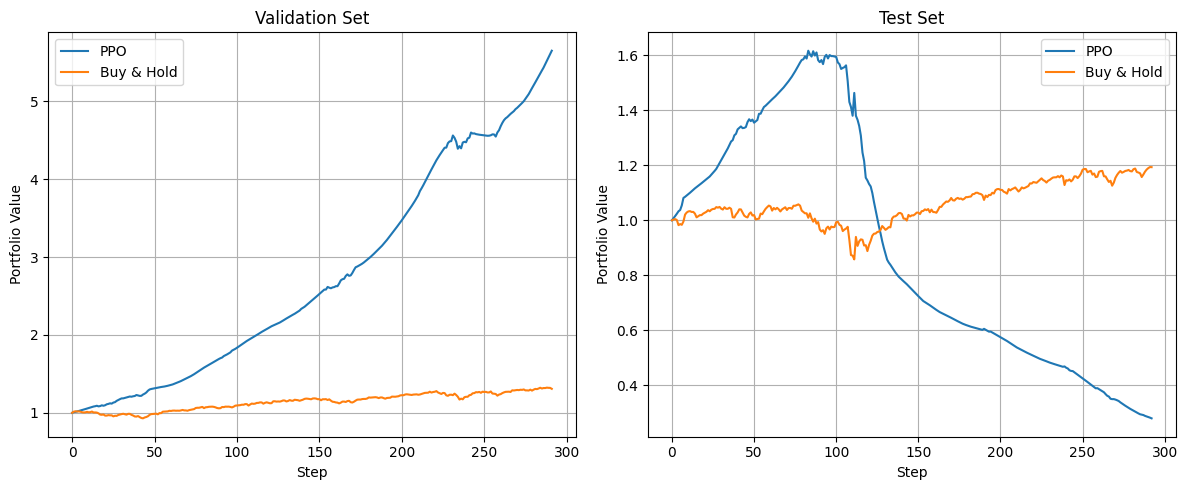

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# Backtest function for normal Gym env
# ======================================
def run_backtest(env, model):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]

    while not done:
        action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        portfolio_values.append(info["portfolio_value"])

    return np.array(portfolio_values)


# ======================================
# Run PPO backtest
# ======================================
val_equity = run_backtest(env_val, model)
test_equity = run_backtest(env_test, model)

print("Validation final value:", val_equity[-1])
print("Test final value:", test_equity[-1])


# ======================================
# Buy & Hold baseline
# ======================================
def buy_hold_curve(df):
    returns = df["raw_return_1d"].values
    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))
    return np.array(equity)


bh_val = buy_hold_curve(df_us_val)
bh_test = buy_hold_curve(df_us_test)


# ======================================
# Plot comparison
# ======================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_equity, label="PPO")
plt.plot(bh_val[:len(val_equity)], label="Buy & Hold")
plt.title("Validation Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_equity, label="PPO")
plt.plot(bh_test[:len(test_equity)], label="Buy & Hold")
plt.title("Test Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def performance_metrics(equity_curve):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns)

    sharpe = np.mean(returns) / (volatility + 1e-8)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_dd = np.max(drawdown)

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = performance_metrics(val_equity)
ppo_test_metrics = performance_metrics(test_equity)

bh_val_metrics = performance_metrics(bh_val[:len(val_equity)])
bh_test_metrics = performance_metrics(bh_test[:len(test_equity)])


# ======================================
# Create comparison table
# ======================================

results = pd.DataFrame({
    
    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,
    
    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics
    
})

print("\nPerformance Comparison")
print(results.round(4))


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
              PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return          4.6491              0.3077   -0.7197        0.1931
Volatility            0.0044              0.0078    0.0111        0.0114
Sharpe Ratio          1.3677              0.1223   -0.3871        0.0587
Max Drawdown          0.0373              0.0882    0.8266        0.1890

Final Portfolio Values
PPO Validation: 5.649145046601656
BuyHold Validation: 1.3076955695072554
PPO Test: 0.2802609187325696
BuyHold Test: 1.193146801647411


In [56]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def compute_metrics(equity_curve):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns) * np.sqrt(252)

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)

    drawdown = (running_max - equity_curve) / running_max

    max_drawdown = np.max(drawdown)

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = compute_metrics(val_equity)
ppo_test_metrics = compute_metrics(test_equity)

bh_val_metrics = compute_metrics(bh_val[:len(val_equity)])
bh_test_metrics = compute_metrics(bh_test[:len(test_equity)])


# ======================================
# Results table
# ======================================

results = pd.DataFrame({

    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,

    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics

})

print("\nPerformance Comparison")
print(results.round(4))


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
              PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return          4.6491              0.3077   -0.7197        0.1931
Volatility            0.0694              0.1236    0.1757        0.1809
Sharpe Ratio         21.7122              1.9418   -6.1447        0.9324
Max Drawdown          0.0373              0.0882    0.8266        0.1890

Final Portfolio Values
PPO Validation: 5.649145046601656
BuyHold Validation: 1.3076955695072554
PPO Test: 0.2802609187325696
BuyHold Test: 1.193146801647411


In [57]:
import pandas as pd

results_table = pd.DataFrame({

    "Metric": ["Total Return", "Volatility", "Sharpe Ratio", "Max Drawdown"],

    "PPO (Validation)": [
        ppo_val_metrics["Total Return"],
        ppo_val_metrics["Volatility"],
        ppo_val_metrics["Sharpe Ratio"],
        ppo_val_metrics["Max Drawdown"]
    ],

    "Buy & Hold (Validation)": [
        bh_val_metrics["Total Return"],
        bh_val_metrics["Volatility"],
        bh_val_metrics["Sharpe Ratio"],
        bh_val_metrics["Max Drawdown"]
    ],

    "PPO (Test)": [
        ppo_test_metrics["Total Return"],
        ppo_test_metrics["Volatility"],
        ppo_test_metrics["Sharpe Ratio"],
        ppo_test_metrics["Max Drawdown"]
    ],

    "Buy & Hold (Test)": [
        bh_test_metrics["Total Return"],
        bh_test_metrics["Volatility"],
        bh_test_metrics["Sharpe Ratio"],
        bh_test_metrics["Max Drawdown"]
    ]

})

print("\nFinal Performance Table")
print(results_table.round(4))


Final Performance Table
         Metric  PPO (Validation)  Buy & Hold (Validation)  PPO (Test)  \
0  Total Return            4.6491                   0.3077     -0.7197   
1    Volatility            0.0694                   0.1236      0.1757   
2  Sharpe Ratio           21.7122                   1.9418     -6.1447   
3  Max Drawdown            0.0373                   0.0882      0.8266   

   Buy & Hold (Test)  
0             0.1931  
1             0.1809  
2             0.9324  
3             0.1890  


In [58]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import random
import torch

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ======================================
# Markets
# ======================================
markets = ["US", "UK", "CN", "HK", "SG"]

all_results = []
all_equity_curves = {}

# Use the same feature setting as previous cells
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

state_features = base_features + regime_features

# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# it must never be scaled
scale_cols = base_features + regime_features

# ======================================
# Utility functions
# ======================================
def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test


def run_backtest_single_env(model, df_eval, state_features):
    eval_env = TradingGymEnv(
        df=df_eval,
        state_features=state_features,
        transaction_cost=0.001,
        lambda_vol=0.01,
        lambda_dd=0.02,
        reward_clip=None
    )

    obs, info = eval_env.reset()
    done = False

    portfolio_values = [1.0]

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        portfolio_values.append(info["portfolio_value"])

    return np.array(portfolio_values)


def buy_hold_curve(df_eval):
    returns = df_eval["raw_return_1d"].values

    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))

    return np.array(equity)


def compute_metrics(equity_curve):
    equity_curve = np.array(equity_curve)

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1
    volatility = np.std(returns) * np.sqrt(252)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_drawdown = np.max(drawdown)

    return total_return, volatility, sharpe, max_drawdown


# ======================================
# Market-by-market training and testing
# ======================================
for market_name in markets:
    print(f"\n========== Training PPO for {market_name} ==========")

    # Prepare market-specific data
    df_market = (
        df_all[df_all["market"] == market_name]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    # Clean data
    df_market = df_market.replace([np.inf, -np.inf], np.nan)
    df_market = df_market.dropna(subset=state_features).reset_index(drop=True)

    # Train / Val / Test split BEFORE scaling
    df_train, df_val, df_test = time_split(df_market, train_ratio=0.6, val_ratio=0.2)

    print(f"{market_name} split sizes -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

    # Scale train only, then transform val / test
    scaler = StandardScaler()
    df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
    df_val[scale_cols] = scaler.transform(df_val[scale_cols])
    df_test[scale_cols] = scaler.transform(df_test[scale_cols])

    # Create training environment
    train_env = DummyVecEnv([
        lambda df=df_train: Monitor(
            TradingGymEnv(
                df=df,
                state_features=state_features,
                transaction_cost=0.001,
                lambda_vol=0.01,
                lambda_dd=0.02,
                reward_clip=None
            )
        )
    ])

    # Train PPO on TRAIN only
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=1e-4,
        n_steps=256,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        seed=SEED
    )

    model.learn(total_timesteps=30000)

    # Save model
    model.save(f"ppo_trading_model_{market_name}")

    # Validation backtest
    val_ppo_curve = run_backtest_single_env(model, df_val, state_features)
    val_bh_curve = buy_hold_curve(df_val)

    # Test backtest
    test_ppo_curve = run_backtest_single_env(model, df_test, state_features)
    test_bh_curve = buy_hold_curve(df_test)

    # Store TEST curves for final plotting
    all_equity_curves[market_name] = {
        "ppo": test_ppo_curve,
        "buy_hold": test_bh_curve[:len(test_ppo_curve)]
    }

    # Compute metrics
    val_ppo_total, val_ppo_vol, val_ppo_sharpe, val_ppo_mdd = compute_metrics(val_ppo_curve)
    val_bh_total, val_bh_vol, val_bh_sharpe, val_bh_mdd = compute_metrics(val_bh_curve[:len(val_ppo_curve)])

    test_ppo_total, test_ppo_vol, test_ppo_sharpe, test_ppo_mdd = compute_metrics(test_ppo_curve)
    test_bh_total, test_bh_vol, test_bh_sharpe, test_bh_mdd = compute_metrics(test_bh_curve[:len(test_ppo_curve)])

    all_results.append({
        "Market": market_name,

        "PPO Val Total Return": val_ppo_total,
        "BH Val Total Return": val_bh_total,
        "PPO Val Volatility": val_ppo_vol,
        "BH Val Volatility": val_bh_vol,
        "PPO Val Sharpe": val_ppo_sharpe,
        "BH Val Sharpe": val_bh_sharpe,
        "PPO Val Max Drawdown": val_ppo_mdd,
        "BH Val Max Drawdown": val_bh_mdd,

        "PPO Test Total Return": test_ppo_total,
        "BH Test Total Return": test_bh_total,
        "PPO Test Volatility": test_ppo_vol,
        "BH Test Volatility": test_bh_vol,
        "PPO Test Sharpe": test_ppo_sharpe,
        "BH Test Sharpe": test_bh_sharpe,
        "PPO Test Max Drawdown": test_ppo_mdd,
        "BH Test Max Drawdown": test_bh_mdd
    })

print("\nAll markets training completed.")


========== Training PPO for US ==========
US split sizes -> Train: 880, Val: 293, Test: 294

========== Training PPO for UK ==========
UK split sizes -> Train: 883, Val: 295, Test: 295

========== Training PPO for CN ==========
CN split sizes -> Train: 849, Val: 283, Test: 283

========== Training PPO for HK ==========
HK split sizes -> Train: 861, Val: 287, Test: 288

========== Training PPO for SG ==========
SG split sizes -> Train: 880, Val: 293, Test: 294

All markets training completed.


In [59]:
# ======================================
# Convert results to DataFrame
# ======================================

results_df = pd.DataFrame(all_results)

print("\nFull Results Table")
print(results_df.round(4))


# ======================================
# Test-set summary (main report table)
# ======================================

test_results = results_df[[
    "Market",
    "PPO Test Total Return",
    "BH Test Total Return",
    "PPO Test Volatility",
    "BH Test Volatility",
    "PPO Test Sharpe",
    "BH Test Sharpe",
    "PPO Test Max Drawdown",
    "BH Test Max Drawdown"
]].copy()

print("\n===== TEST SET PERFORMANCE =====")
print(test_results.round(4))


# ======================================
# Sharpe ranking (useful diagnostic)
# ======================================

ranking = test_results.sort_values("PPO Test Sharpe", ascending=False)

print("\n===== PPO Sharpe Ranking =====")
print(ranking[["Market", "PPO Test Sharpe"]].round(4))


Full Results Table
  Market  PPO Val Total Return  BH Val Total Return  PPO Val Volatility  \
0     US                4.6491               0.3077              0.0694   
1     UK                6.5642               0.1099              0.0557   
2     CN               -0.7545               0.0459              0.3328   
3     HK                0.0338               0.1364              0.1855   
4     SG                1.8935               0.1159              0.0976   

   BH Val Volatility  PPO Val Sharpe  BH Val Sharpe  PPO Val Max Drawdown  \
0             0.1236         21.7122         1.9418                0.0373   
1             0.0975         31.3628         0.9683                0.0065   
2             0.1824         -3.6018         0.3112                0.8824   
3             0.2523          0.2523         0.5746                0.4124   
4             0.1046          9.4962         0.9605                0.1371   

   BH Val Max Drawdown  PPO Test Total Return  BH Test Total Retur

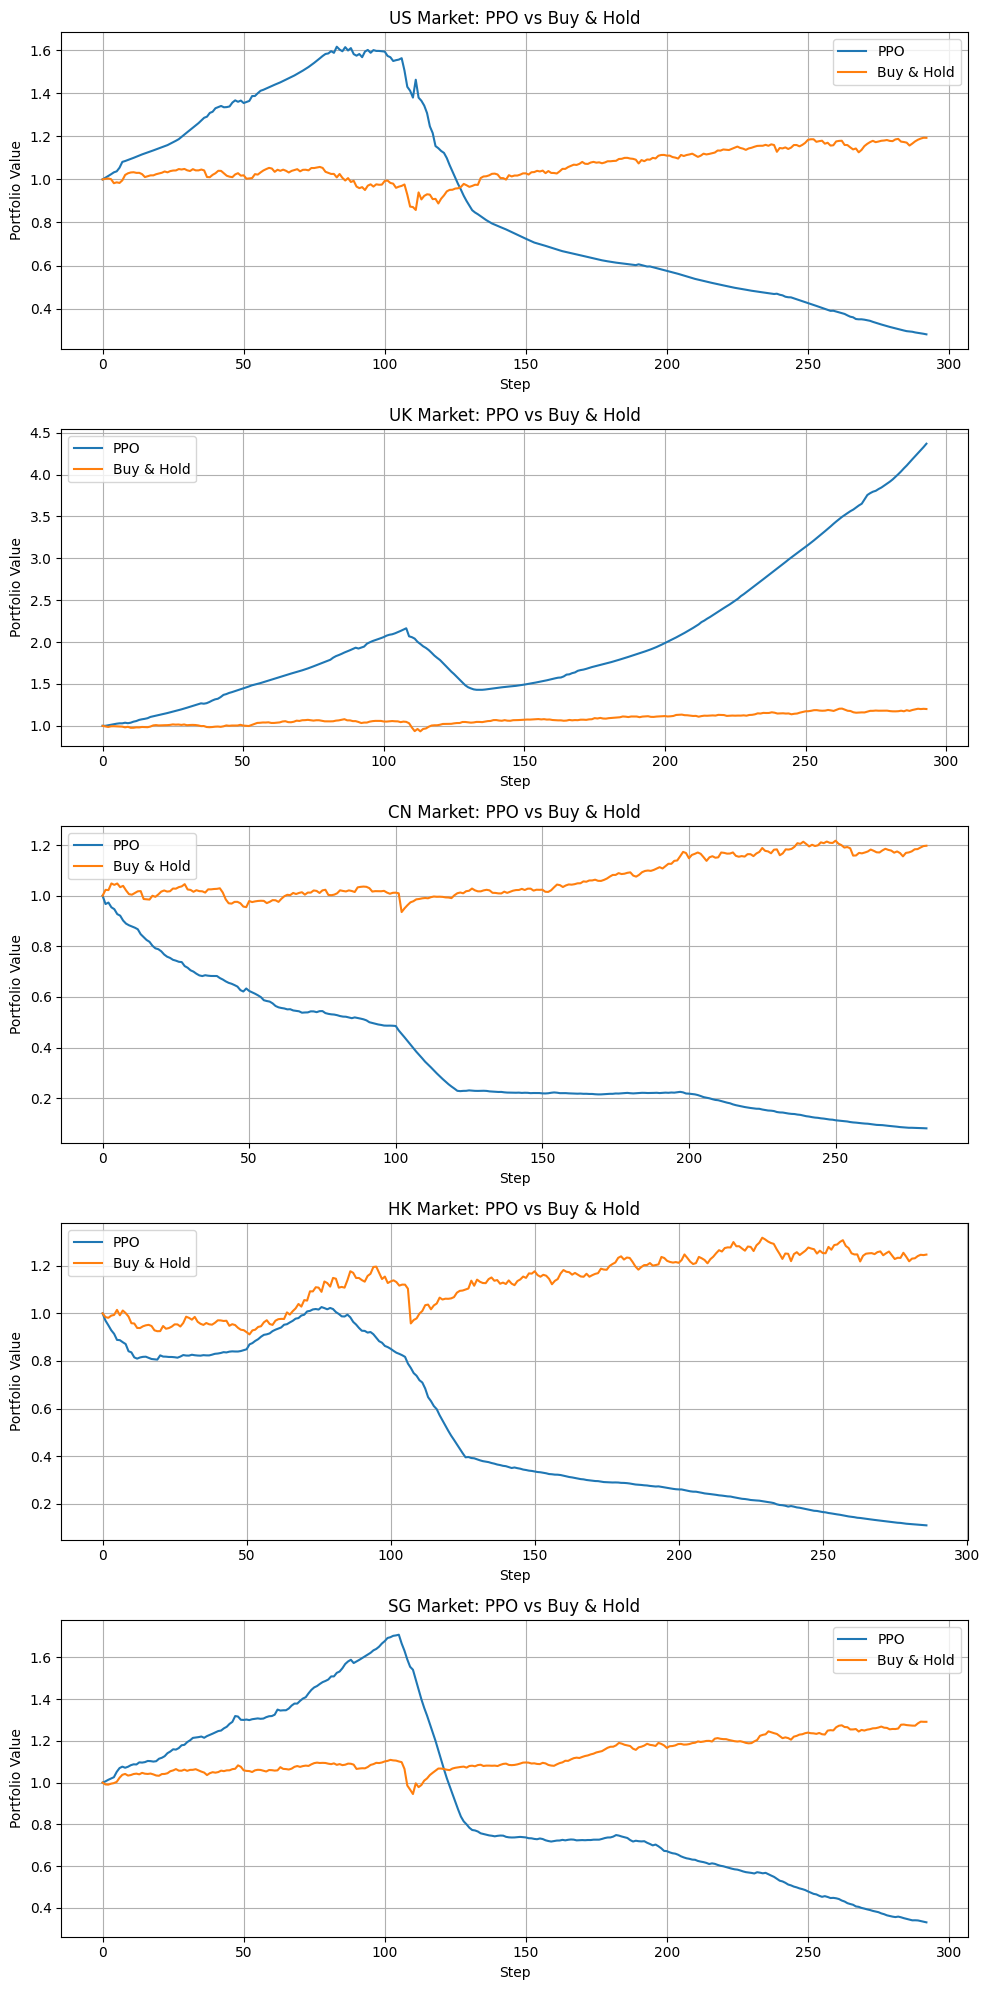

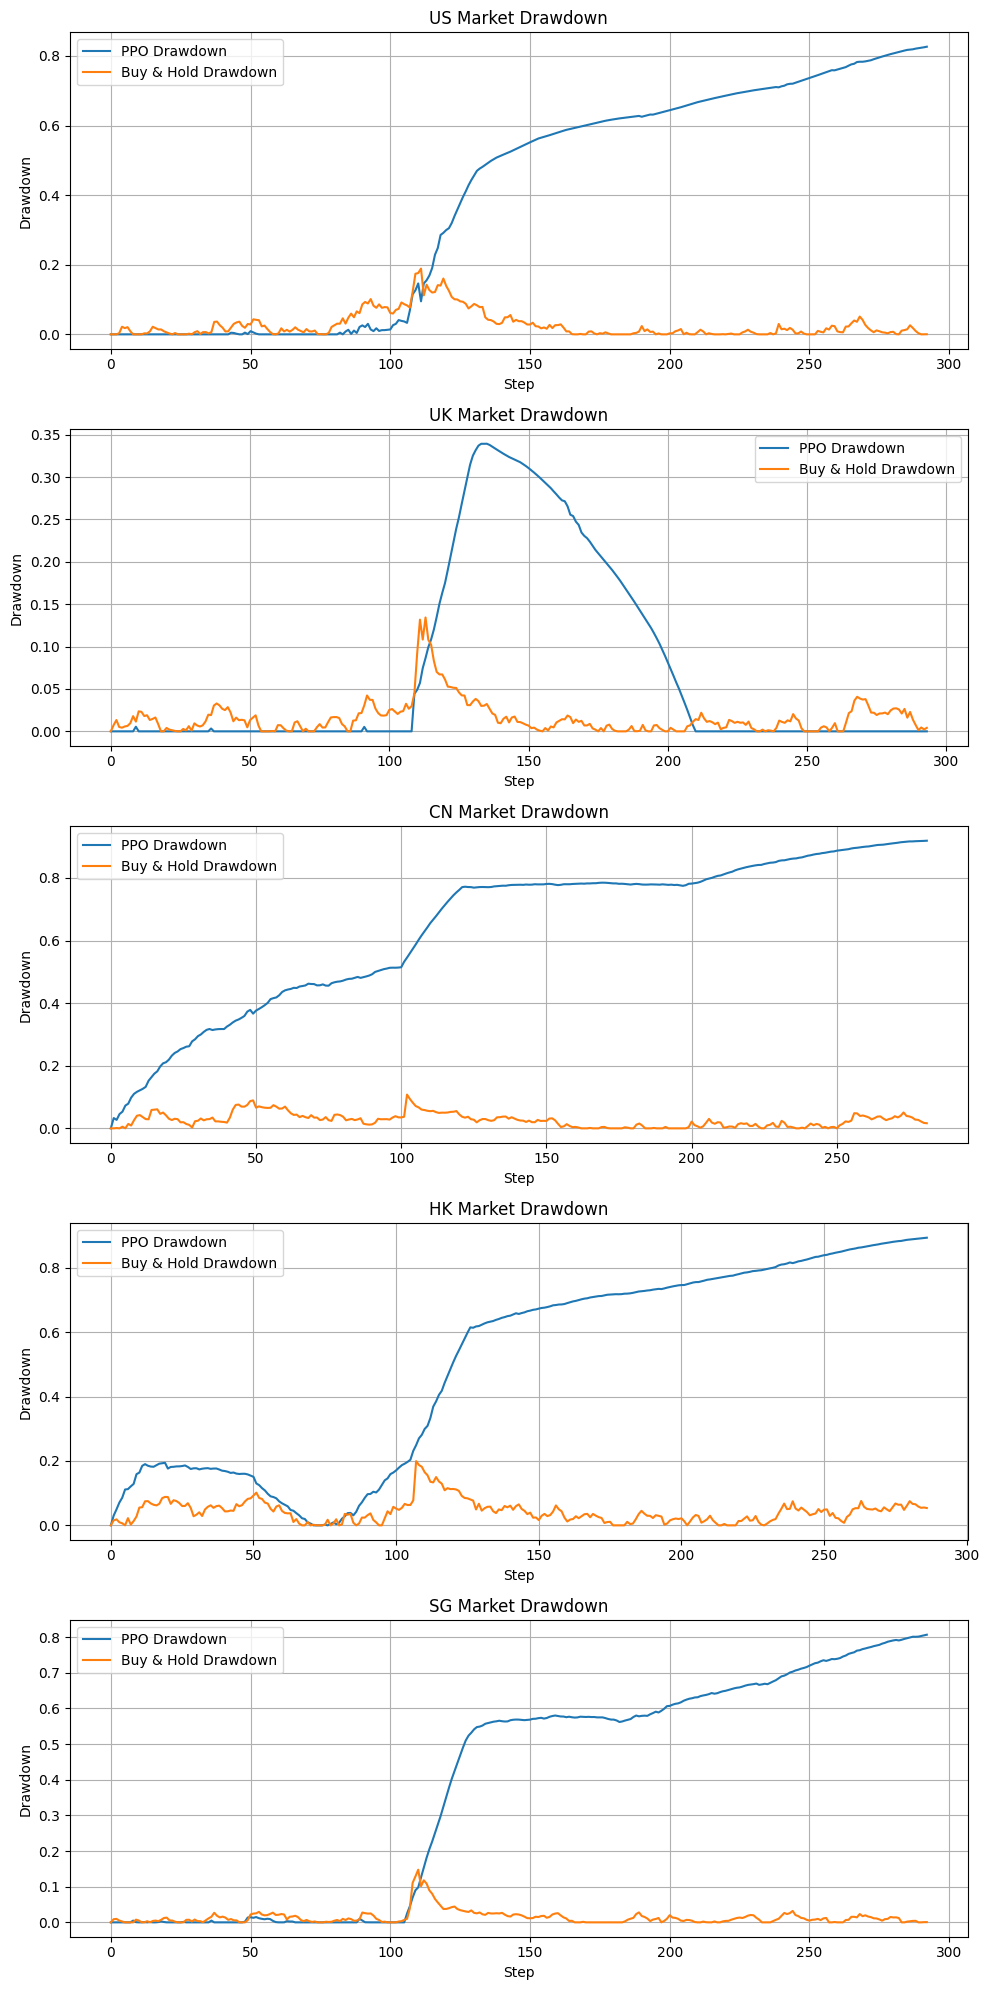

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# Helper: compute drawdown
# ======================================
def compute_drawdown(equity):
    equity = np.array(equity)
    running_max = np.maximum.accumulate(equity)
    drawdown = (running_max - equity) / running_max
    return drawdown


# ======================================
# Equity curves (all markets)
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ax.plot(ppo_curve, label="PPO")
    ax.plot(bh_curve, label="Buy & Hold")

    ax.set_title(f"{market_name} Market: PPO vs Buy & Hold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Portfolio Value")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# ======================================
# Drawdown curves
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ppo_dd = compute_drawdown(ppo_curve)
    bh_dd = compute_drawdown(bh_curve)

    ax.plot(ppo_dd, label="PPO Drawdown")
    ax.plot(bh_dd, label="Buy & Hold Drawdown")

    ax.set_title(f"{market_name} Market Drawdown")
    ax.set_xlabel("Step")
    ax.set_ylabel("Drawdown")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()